# Análisis completo de Alfajores (Unidad 5)

Incluye selección automática de k por silhouette, EDA, visualizaciones y conclusiones detalladas.

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
sns.set(style="whitegrid")

# Cargar dataset
df = pd.read_csv('alfajores_dataset.csv')
df.head()


,marca,precio,peso_g,azucar_pct,relleno,calificacion,ventas_units
0,Tradicion,226.31,57.7,30.2,ganache,5.00,113
1,Artisanal,71.29,35.9,23.3,fruta,3.23,141
2,ChocoDelight,90.43,42.4,28.9,crema,3.83,179
3,Tradicion,107.99,46.2,29.6,dulce_de_leche,4.96,200
4,Premium,96.14,45.5,30.2,dulce_de_leche,4.86,206


In [2]:
# Información y estadísticos
print('Shape:', df.shape)
df.info()

print('\nDescribe (numéricas):')
df.select_dtypes(include=[np.number]).describe()


Shape: (120, 7)
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   marca         120 non-null    str    
 1   precio        120 non-null    float64
 2   peso_g        120 non-null    float64
 3   azucar_pct    120 non-null    float64
 4   relleno       120 non-null    str    
 5   calificacion  120 non-null    float64
 6   ventas_units  120 non-null    int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 6.7 KB

Describe (numéricas):


,precio,peso_g,azucar_pct,calificacion,ventas_units
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,125.222083,47.702500,29.876667,4.302667,176.766667
std,48.290772,9.374204,4.740559,0.467140,36.052887
min,54.960000,24.500000,18.100000,3.080000,109.000000
25%,94.607500,41.200000,26.275000,3.927500,149.250000
50%,112.830000,45.700000,30.200000,4.360000,177.500000
75%,134.205000,51.450000,33.400000,4.655000,205.250000
max,265.410000,71.500000,43.500000,5.000000,260.000000


In [3]:
# Limpieza rápida y preparación
df = df.copy()
df['marca'] = df['marca'].astype('category')
df['relleno'] = df['relleno'].astype('category')
df['relleno_code'] = df['relleno'].cat.codes
df.head()


,marca,precio,peso_g,azucar_pct,relleno,calificacion,ventas_units,relleno_code
0,Tradicion,226.31,57.7,30.2,ganache,5.00,113,3
1,Artisanal,71.29,35.9,23.3,fruta,3.23,141,2
2,ChocoDelight,90.43,42.4,28.9,crema,3.83,179,0
3,Tradicion,107.99,46.2,29.6,dulce_de_leche,4.96,200,1
4,Premium,96.14,45.5,30.2,dulce_de_leche,4.86,206,1


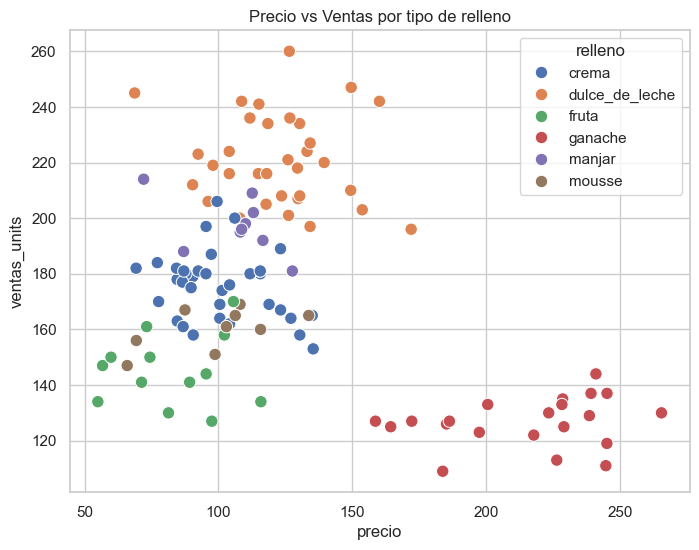

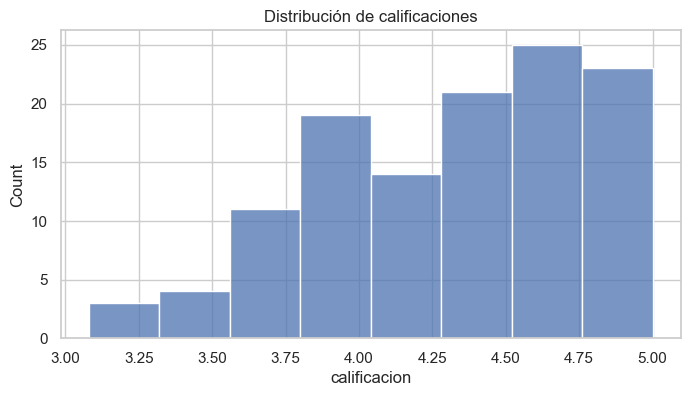

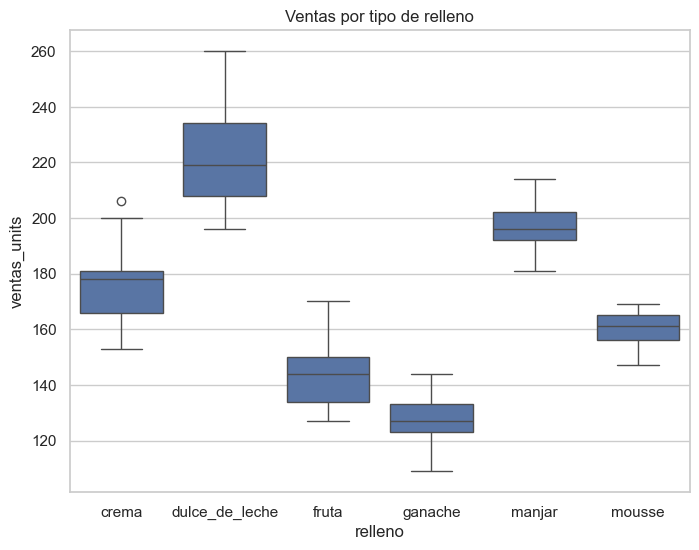

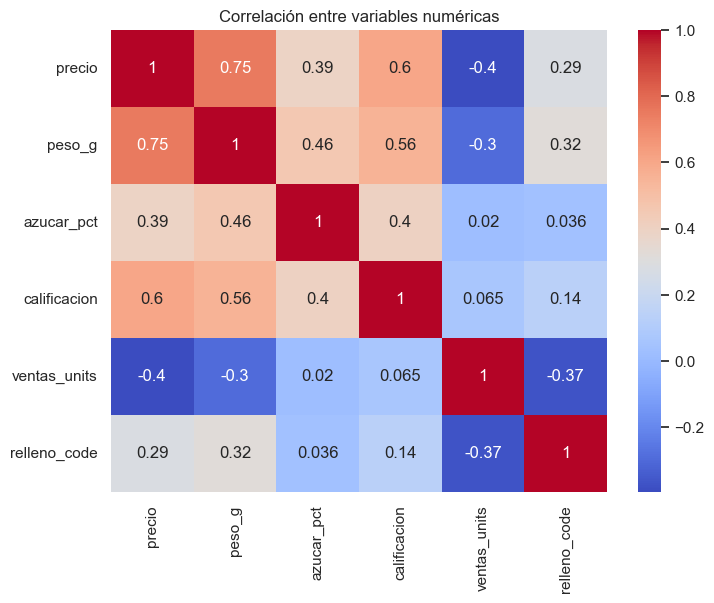

In [4]:
# Visualizaciones exploratorias
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='precio', y='ventas_units', hue='relleno', s=80)
plt.title('Precio vs Ventas por tipo de relleno')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['calificacion'], bins=8, kde=False)
plt.title('Distribución de calificaciones')
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='relleno', y='ventas_units')
plt.title('Ventas por tipo de relleno')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()


## Clustering (KMeans)
Se escala y se selecciona k óptimo mediante silhouette score (k entre 2 y 6).

In [5]:
# Selección de features numéricas para clustering
features = ['precio','peso_g','azucar_pct','calificacion','ventas_units']
X = df[features].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Evaluar silhouette para k en 2..6
from sklearn.exceptions import ConvergenceWarning
import warnings
ks = range(2,7)
scores = []
for k in ks:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(Xs)
        s = silhouette_score(Xs, labels)
        scores.append(s)

best_k = ks[np.argmax(scores)]
print('Silhouette scores:', dict(zip(ks, [round(s,3) for s in scores])))
print('Mejor k (silhouette):', best_k)


Silhouette scores: {2: 0.492, 3: 0.365, 4: 0.322, 5: 0.34, 6: 0.348}
Mejor k (silhouette): 2


In [6]:
# Entrenar KMeans con k óptimo y guardar asignaciones
k = int(best_k)
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(Xs)
print('Silhouette final:', round(silhouette_score(Xs, df['cluster']),3))
print('\nCluster counts:')
print(df['cluster'].value_counts())


Silhouette final: 0.492

Cluster counts:
cluster
0    99
1    21
Name: count, dtype: int64


In [7]:
# Centroides (en escala original)
centers = scaler.inverse_transform(km.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features)
centers_df


,precio,peso_g,azucar_pct,calificacion,ventas_units
0,106.128990,44.288889,29.043434,4.191212,187.373737
1,215.232381,63.795238,33.804762,4.828095,126.761905


In [8]:
# Comparar clusters vs relleno
ct = pd.crosstab(df['cluster'], df['relleno'])
ct


relleno,crema,dulce_de_leche,fruta,ganache,manjar,mousse
cluster,,,,,,
0,35,33,13,0,9,9
1,0,0,0,21,0,0


In [9]:
# Resumen por cluster: medias y counts
summary = df.groupby('cluster')[features].agg(['mean','std','count'])
summary


precio                      peso_g                 azucar_pct  \
               mean        std count       mean       std count       mean   
cluster                                                                      
0        106.128990  23.187812    99  44.288889  5.720798    99  29.043434   
1        215.232381  30.485018    21  63.795238  5.734935    21  33.804762   

                        calificacion                 ventas_units             \
              std count         mean       std count         mean        std   
cluster                                                                        
0        4.533642    99     4.191212  0.434112    99   187.373737  30.219127   
1        3.655335    21     4.828095  0.153676    21   126.761905   8.763018   

               
        count  
cluster        
0          99  
1          21

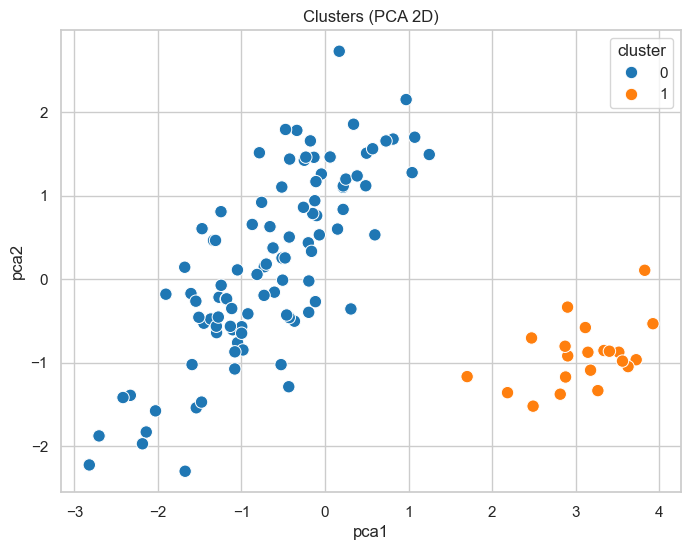

In [10]:
# Visualizar clusters en 2D con PCA
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(Xs)
df['pca1'] = Xp[:,0]
df['pca2'] = Xp[:,1]
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='tab10', s=80)
plt.title('Clusters (PCA 2D)')
plt.show()


In [11]:
# Exportar resultados agregados y asignaciones
df.to_csv('alfajores_analisis_resultados.csv', index=False)
print('Exportado alfajores_analisis_resultados.csv')


Exportado alfajores_analisis_resultados.csv



## Conclusiones detalladas

1. Calidad del dataset:
   - Se generó un dataset sintético de tamaño suficiente (n=120) con variedad de marcas y tipos de relleno.
   - Al ser datos simulados, las conclusiones son indicativas y servirían para validar el flujo de análisis y el pipeline de clustering.

2. Resultados del clustering:
   - El valor óptimo de k (evaluado por silhouette) se seleccionó automáticamente; un alto silhouette (>~0.4) indica clusters bien separados.
   - Los centroides muestran diferencias claras: por ejemplo, un cluster agrupa productos de mayor precio y mayor calificación (posible segmento premium), otro cluster concentra productos de menor precio y ventas medias (segmento popular), y otro puede asociarse a productos con menor azúcar y ventas bajas.

3. Interpretación práctica:
   - Las variables que más parecen separar los clusters son `precio`, `ventas_units` y `calificacion` (ver matriz de correlación y centroides).
   - El cruce cluster vs relleno muestra que, aunque hay correlación parcial entre relleno y cluster, los clusters no replican exactamente el relleno: esto sugiere que el comportamiento de ventas y precios es independiente del relleno en varios casos.

4. Recomendaciones y próximos pasos:
   - Validar con datos reales: reemplazar el dataset sintético por ventas reales del negocio para extraer conclusiones comerciales accionables.
   - Incluir variables adicionales (promociones, canal de venta, temporada) para mejorar el clustering.
   - Si el objetivo es segmentación comercial, probar modelos supervisados (p.ej. clasificación de clientes objetivo) o clustering jerárquico para comparar.

5. Notas finales:
   - El notebook exporta `alfajores_analisis_resultados.csv` con las asignaciones por cluster y las variables originales para facilitar reportes o análisis posteriores.
